## 1. Initial Data Exploration

A random sample of the dataset is displayed to quickly understand its structure, variable types, and general composition without introducing positional bias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("raw_table.csv")

data.sample(5)

,NUEVO_ID,WEEK_ID,UC_TRX,ORAL_TRX,IL23_TRX,BRAND1_TRX,BRAND2_TRX,UC_NRX,ORAL_NRX,IL23_NRX,...,STATE_6,STS_OTHER_STS,STATE_7,STATE_8,"(1940, 1960]","(1960, 1980]","(1980, 2000]","(2000, 2020]","(2020, 2030]",ATSEG
603178,16186,2025-03-14,0.0000,0.0000,0.0,0.0,0.0,0.0000,0.0,0.0,...,0,1,0,0,0,0,1,0,0,SEG_A
937209,4423,2025-03-21,0.1834,0.1834,0.0,0.0,0.0,0.0000,0.0,0.0,...,0,1,0,0,0,1,0,0,0,SEG_A
464282,11876,2024-11-15,0.1662,0.0000,0.0,0.0,0.0,0.2493,0.0,0.0,...,0,1,0,0,0,0,1,0,0,SEG_C
470489,19478,2024-08-02,0.0000,0.0000,0.0,0.0,0.0,0.0000,0.0,0.0,...,0,0,0,0,0,0,1,0,0,NaN
633929,6337,2024-10-25,0.1960,0.0000,0.0,0.0,0.0,0.0000,0.0,0.0,...,0,1,0,0,0,1,0,0,0,SEG_C


## 2. Dataset Scale and Structure

The dataset contains a large number of observations and features, with the majority of variables being numerical, indicating a structured dataset suitable for quantitative analysis.

In [2]:
print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")

print(data.dtypes.value_counts())

Rows: 1,800,066
Columns: 68
float64    42
int64      24
object      2
Name: count, dtype: int64


## 3. Temporal Behavior of the Dataset

The dataset spans a continuous time period and shows a consistent number of observations per month, indicating stable data collection over time.

2024-01-05 00:00:00 2025-08-22 00:00:00


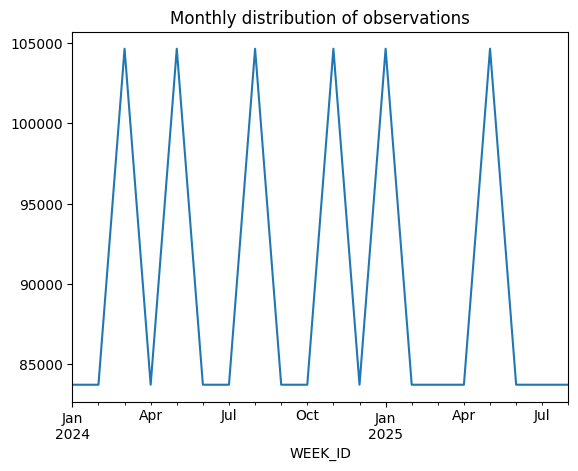

In [3]:
data["WEEK_ID"] = pd.to_datetime(data["WEEK_ID"])

print(data["WEEK_ID"].min(), data["WEEK_ID"].max())

data["WEEK_ID"].dt.to_period("M").value_counts().sort_index().plot()
plt.title("Monthly distribution of observations")
plt.show()

## 4. Entity Consistency (Doctor-Level Analysis)

The single concentrated bar in the distribution confirms that all doctors have identical observation counts, indicating a fully balanced panel dataset.

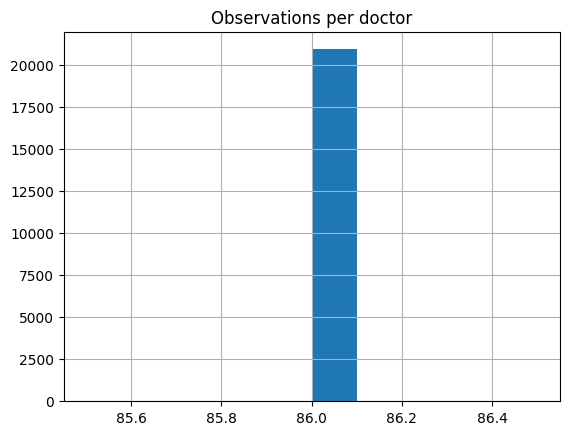

In [4]:
data.duplicated(subset=["NUEVO_ID", "WEEK_ID"]).sum()

doctor_activity = data.groupby("NUEVO_ID").size()

doctor_activity.hist()
plt.title("Observations per doctor")
plt.show()

## 5. Data Completeness

The dataset is largely complete, with missing values concentrated only in the target variable, suggesting partial segmentation coverage rather than data quality issues.

In [5]:
missing = data.isnull().mean().sort_values(ascending=False)
missing.head(10)

,0
ATSEG,0.431513
NUEVO_ID,0.000000
UC_TRX,0.000000
WEEK_ID,0.000000
ORAL_TRX,0.000000
IL23_TRX,0.000000
BRAND2_TRX,0.000000
BRAND1_TRX,0.000000
ORAL_NRX,0.000000
IL23_NRX,0.000000


## 6. Feature Stability and Redundancy

Constant features indicate the absence of observations in certain categories and should be removed, as they do not provide any discriminatory power.

In [6]:
[col for col in data.columns if data[col].nunique() <= 1]

['(2000, 2020]', '(2020, 2030]']

## 7. Event Sparsity Analysis

The dataset exhibits a high level of sparsity, meaning that most variables contain a large proportion of zero values, indicating that many events occur infrequently.

In [7]:
zero_ratio = (data.select_dtypes(include=["float64", "int64"]) == 0).mean()

zero_ratio.sort_values(ascending=False).head(10)

,0
"(2000, 2020]",1.000000
"(2020, 2030]",1.000000
N_CLMBRAND1_NEW,0.999658
N_CLMBRAND1_NEW_TO_BRAND,0.999185
BRAND1_NBRX,0.999184
BRAND2_NBRX,0.998987
BRAND1_NRX,0.998912
N_CLMBRAND2_NEW_TO_BRAND,0.998890
SPK,0.998739
N_CLMBRAND4_NEW_TO_BRAND,0.998379


## 8. Distribution Patterns and Skewness

Log-transformed distributions reveal that prescription variables are highly skewed, with most observations concentrated near zero and a small number of high-value cases.

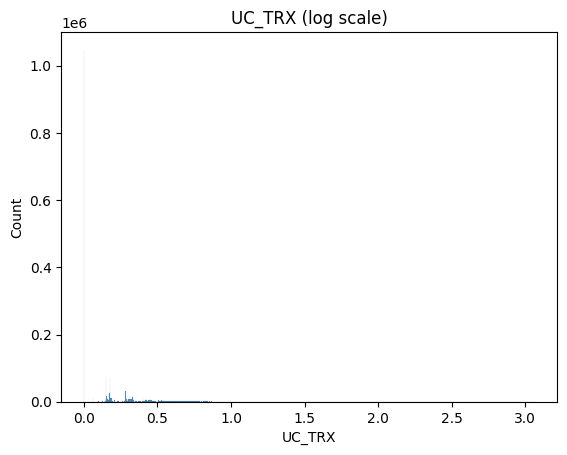

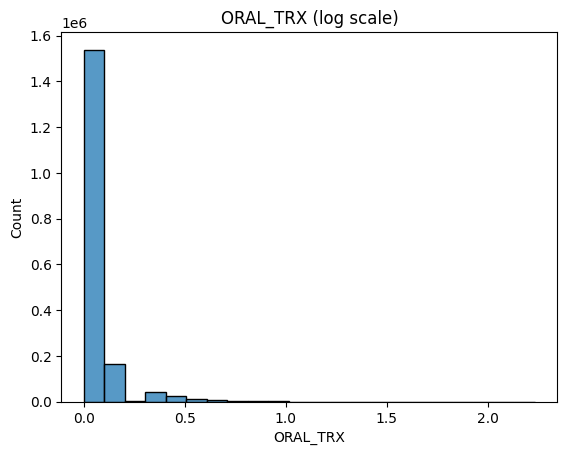

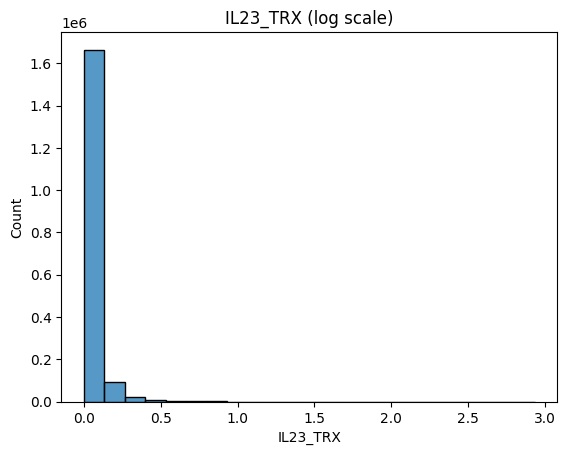

In [8]:
cols = ["UC_TRX", "ORAL_TRX", "IL23_TRX"]

for col in cols:
    sns.histplot(np.log1p(data[col]))
    plt.title(f"{col} (log scale)")
    plt.show()

## 9. High-Activity Behavior (Outliers)

High-activity doctors are predominantly concentrated in SEG_C, suggesting that this segment captures the most influential prescribers.

In [9]:
high_activity = data[data["UC_TRX"] > data["UC_TRX"].quantile(0.99)]

high_activity["ATSEG"].value_counts()

,count
ATSEG,
SEG_C,10189
SEG_B,5747
SEG_A,210


## 10. Feature Relationship

The weak positive correlation suggests that engagement may have a limited influence on prescription behavior, indicating that other factors likely play a more significant role.

In [10]:
data["TOTAL_PRESCRIPTIONS"] = data["UC_TRX"] + data["ORAL_TRX"] + data["IL23_TRX"]

data["ENGAGEMENT_INDEX"] = data[["RTE", "DETAILS", "SAMPLES"]].sum(axis=1)

data[["TOTAL_PRESCRIPTIONS", "ENGAGEMENT_INDEX"]].corr()

,TOTAL_PRESCRIPTIONS,ENGAGEMENT_INDEX
TOTAL_PRESCRIPTIONS,1.00000,0.08088
ENGAGEMENT_INDEX,0.08088,1.00000


## 11. Segment Behavior Analysis

This analysis compares average prescription activity and engagement levels across segments to identify behavioral differences among groups. The alignment between higher prescription activity and engagement levels suggests that segment classification effectively captures meaningful behavioral differences among physicians.

In [11]:
data.groupby("ATSEG")[["TOTAL_PRESCRIPTIONS", "ENGAGEMENT_INDEX"]].mean()

,TOTAL_PRESCRIPTIONS,ENGAGEMENT_INDEX
ATSEG,,
SEG_A,0.207362,0.099678
SEG_B,0.702715,0.170258
SEG_C,0.945165,0.173163


## 12. Segment Distribution and Bias

The distribution of the target variable reveals both class imbalance and a significant proportion of missing segment labels, indicating partial segmentation coverage. he high proportion of missing segment labels, combined with class imbalance, indicates that segmentation is incomplete and unevenly distributed across the dataset.

In [12]:
data["ATSEG"].value_counts(normalize=True, dropna=False) * 100

,proportion
ATSEG,
NaN,43.151307
SEG_A,30.605322
SEG_B,16.000191
SEG_C,10.243180


## 13. Behavioral Consistency (Doctor Stability)

This analysis evaluates how consistent doctors are over time in their prescription behavior by measuring the variability of their activity. Most doctors exhibit stable prescription behavior over time, while a smaller subset shows significant variability, indicating heterogeneous behavioral patterns.

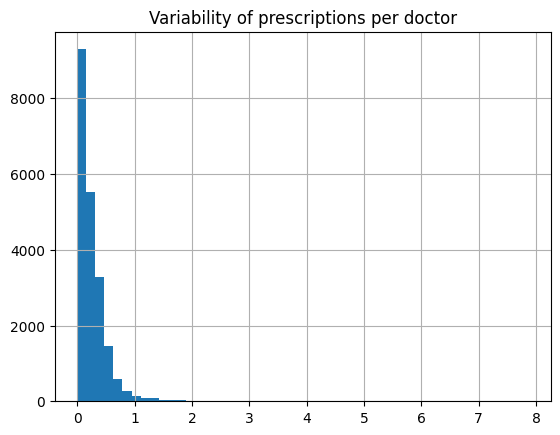

In [13]:
doctor_std = data.groupby("NUEVO_ID")["TOTAL_PRESCRIPTIONS"].std()

doctor_std.hist(bins=50)
plt.title("Variability of prescriptions per doctor")
plt.show()

## 14. Engagement Effect Segmentation

A scatter plot is used to explore the relationship between engagement and prescription activity, allowing visualization of potential patterns between marketing interactions and doctor behavior.
The absence of a clear pattern suggests that engagement alone is not a strong predictor of prescription activity.

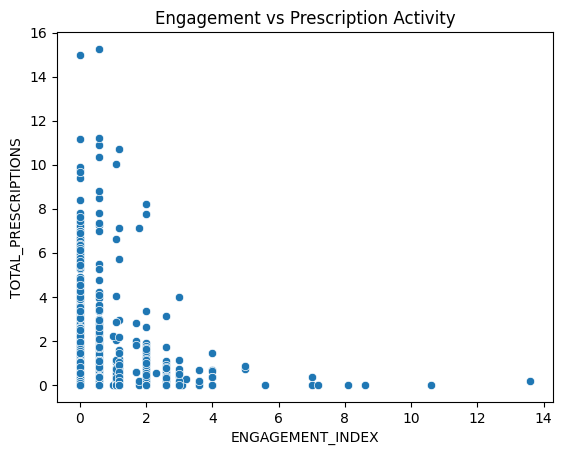

In [14]:
sns.scatterplot(x="ENGAGEMENT_INDEX", y="TOTAL_PRESCRIPTIONS", data=data.sample(10000))
plt.title("Engagement vs Prescription Activity")
plt.show()

## 15. Top Performers Identification

op-performing doctors are identified based on their average prescription activity, highlighting those who contribute the most to overall volume.

In [15]:
top_doctors = data.groupby("NUEVO_ID")["TOTAL_PRESCRIPTIONS"].mean().nlargest(10)
top_doctors

,TOTAL_PRESCRIPTIONS
NUEVO_ID,
10974,22.334751
3478,20.132077
9958,14.160826
9122,13.344395
7612,13.020930
7687,12.675702
16211,12.575619
11950,12.416226
10106,10.923223


## 16. Segment Transition

This step evaluates the distribution of a binary representation of the target variable, allowing a simplified view of segment presence versus absence. The binary distribution shows that a substantial portion of doctors have assigned segments, although a significant fraction remains unlabeled.

In [16]:
segment_changes = data.groupby("NUEVO_ID")["ATSEG"].nunique()

segment_changes.value_counts()

,count
ATSEG,
1,11899
0,9032


# Final Conclusion

The exploratory data analysis reveals that the dataset is a well-structured and balanced panel at the doctor-week level, with consistent observations across all physicians over time. This ensures reliable longitudinal analysis without biases caused by missing time periods.

From a behavioral perspective, the data shows strong sparsity and right-skewed distributions, indicating that most doctors exhibit low prescription activity, while a small subset concentrates a disproportionately high volume. This pattern is further confirmed by the identification of top-performing doctors, reflecting a typical Pareto-like distribution.

Segment-level analysis highlights clear behavioral differences across groups. SEG_C represents the most active and engaged doctors, followed by SEG_B, while SEG_A corresponds to low-activity profiles. This gradient suggests that the segmentation effectively captures meaningful differences in physician behavior.

However, the dataset also presents important limitations. A significant proportion of observations lacks segment labels, indicating incomplete segmentation coverage. Additionally, the distribution of segments is imbalanced, which may introduce bias in downstream analysis or predictive modeling.

The relationship between engagement and prescription activity appears weak, as evidenced by both low correlation and high dispersion in the data. This suggests that engagement alone is not a strong driver of prescription behavior, and that additional factors likely influence physician decisions.

Finally, variability analysis shows that while most doctors maintain stable behavior over time, a smaller group exhibits high fluctuations, representing potential opportunities for targeted strategies.